<a href="https://colab.research.google.com/github/jangirsachin9619-cpu/ML-a2-Global-Pollution-Analysis-and-Energy-Recovery/blob/main/mla2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path=('/content/drive/MyDrive/Global_Pollution_Analysis.csv')
df=pd.read_csv(path)
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [7]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [10]:
fill_null_values = df.select_dtypes(include=['number']).mean()
df.fillna(fill_null_values, inplace=True)

In [11]:
fill_null_values = df.select_dtypes(include=['number']).mean()

In [15]:
import pandas as pd

df_reloaded = pd.read_csv(path)
df_reloaded['Year'] = pd.to_datetime(df_reloaded['Year'], format='%Y')

df_reloaded['Year_Numeric'] = df_reloaded['Year'].dt.year
df_reloaded.sort_values(by=['Country', 'Year_Numeric'], inplace=True)

df_reloaded['Air_Pollution_Index_Lag1'] = df_reloaded.groupby('Country')['Air_Pollution_Index'].shift(1)
df_reloaded['CO2_Emissions_Lag1'] = df_reloaded.groupby('Country')['CO2_Emissions (in MT)'].shift(1)

print("DataFrame head with new 'Year_Numeric' and lag features:")
print(df_reloaded.head())
print("\nMissing values introduced by lag features:")
print(df_reloaded[['Air_Pollution_Index_Lag1', 'CO2_Emissions_Lag1']].isnull().sum())

DataFrame head with new 'Year_Numeric' and lag features:
         Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
120  Afghanistan 2002-01-01               202.26                 138.90   
188  Afghanistan 2006-01-01               105.10                  82.34   
78       Albania 2006-01-01               152.21                 110.41   
90       Andorra 2005-01-01               189.39                  46.83   
24        Angola 2016-01-01               221.40                 192.86   

     Soil_Pollution_Index  Industrial_Waste (in tons)  \
120                 45.10                    43576.51   
188                 84.06                    20688.64   
78                  86.94                    93094.36   
90                  91.86                    33356.33   
24                  36.32                    33021.64   

     Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
120                     150.10                   9.58                 

In [13]:
df_raw = pd.read_csv(path)
df_raw = df_raw.sort_values(by=['Country', 'Year'])
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']

for col in pollution_columns:
    df_raw[f'{col}_YoY_Growth'] = df_raw.groupby('Country')[col].pct_change() * 100


print(df_raw.head())

         Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
120  Afghanistan  2002               202.26                 138.90   
188  Afghanistan  2006               105.10                  82.34   
78       Albania  2006               152.21                 110.41   
90       Andorra  2005               189.39                  46.83   
24        Angola  2016               221.40                 192.86   

     Soil_Pollution_Index  Industrial_Waste (in tons)  \
120                 45.10                    43576.51   
188                 84.06                    20688.64   
78                  86.94                    93094.36   
90                  91.86                    33356.33   
24                  36.32                    33021.64   

     Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
120                     150.10                   9.58                 34.61   
188                     146.28                  34.82                  6.23   

In [14]:
df_reloaded = pd.read_csv(path)
df_reloaded['Year'] = pd.to_datetime(df_reloaded['Year'], format='%Y')

print(df_reloaded.head())

        Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary 2005-01-01               272.70                 124.27   
1     Singapore 2001-01-01                86.72                  60.34   
2       Romania 2016-01-01                91.59                  83.36   
3  Cook Islands 2018-01-01               280.61                  67.16   
4      Djibouti 2008-01-01               179.16                 127.53   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                 51.95                    94802.83   
1                117.22                    56283.92   
2                121.72                    56256.02   
3                 93.58                    74864.73   
4                121.55                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36

In [16]:
df_raw['Year'] = pd.to_datetime(df_raw['Year'], format='%Y')

growth_columns = [f'{col}_YoY_Growth' for col in pollution_columns]
df_reloaded = pd.merge(
    df_reloaded,
    df_raw[['Country', 'Year'] + growth_columns],
    on=['Country', 'Year'],
    how='left'
)

print(df_reloaded.head())

       Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
0  Afghanistan 2002-01-01               202.26                 138.90   
1  Afghanistan 2006-01-01               105.10                  82.34   
2      Albania 2006-01-01               152.21                 110.41   
3      Andorra 2005-01-01               189.39                  46.83   
4       Angola 2016-01-01               221.40                 192.86   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                 45.10                    43576.51   
1                 84.06                    20688.64   
2                 86.94                    93094.36   
3                 91.86                    33356.33   
4                 36.32                    33021.64   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     150.10                   9.58                 34.61   
1                     146.28                  34.82                  6.23   

In [17]:
from sklearn.preprocessing import MinMaxScaler
column_to_standardize = ['Air_Pollution_Index','Water_Pollution_Index','Soil_Pollution_Index']
scaler=MinMaxScaler()
df[column_to_standardize] = scaler.fit_transform(df[column_to_standardize])
print(df.head())

        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005             0.898042               0.553778   
1     Singapore  2001             0.147062               0.173673   
2       Romania  2016             0.166727               0.310542   
3  Cook Islands  2018             0.929982               0.214222   
4      Djibouti  2008             0.520331               0.573161   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0              0.295481                    94802.83   
1              0.768178                    56283.92   
2              0.800768                    56256.02   
3              0.596973                    74864.73   
4              0.799537                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44   
2                     4

In [18]:
#Encoding
df_encoded = pd.get_dummies(df['Country'], prefix='Country', drop_first=True)
df = pd.concat([df, df_encoded], axis=1)
df.drop('Country', axis=1, inplace=True)
print(df.head())

   Year  Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
0  2005             0.898042               0.553778              0.295481   
1  2001             0.147062               0.173673              0.768178   
2  2016             0.166727               0.310542              0.800768   
3  2018             0.929982               0.214222              0.596973   
4  2008             0.520331               0.573161              0.799537   

   Industrial_Waste (in tons)  Energy_Recovered (in GWh)  \
0                    94802.83                     158.14   
1                    56283.92                     498.04   
2                    56256.02                     489.51   
3                    74864.73                     145.18   
4                    76862.06                      40.38   

   CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                   5.30                 41.11   
1                   6.34                 36.44   
2                  49.69  

In [19]:
#EDA
numerical_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
print('Mean:')
print(df[numerical_columns].mean())
print('\nStandard Deviation:')
print(df[numerical_columns].std())
print('\nmode:')
print(df[numerical_columns].mode())
print('\nmedian:')
print(df[numerical_columns].median())
print('\nQuantiles:')
print(df[numerical_columns].quantile())
print('\nVariance:')
print(df[numerical_columns].var())

Mean:
Air_Pollution_Index      0.526255
Water_Pollution_Index    0.499067
Soil_Pollution_Index     0.473193
dtype: float64

Standard Deviation:
Air_Pollution_Index      0.270839
Water_Pollution_Index    0.282900
Soil_Pollution_Index     0.287462
dtype: float64

mode:
     Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index
0               0.259035               0.000000              0.000000
1               0.408076               0.001784              0.004490
2                    NaN               0.003151              0.004925
3                    NaN               0.003924              0.006590
4                    NaN               0.026220              0.006952
..                   ...                    ...                   ...
195                  NaN               0.961591              0.977549
196                  NaN               0.962126              0.978491
197                  NaN               0.983114              0.979794
198                  NaN        

In [20]:
numerical_features_to_describe = ['CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']

print('Descriptive Statistics for CO2_Emissions (in MT) and Industrial_Waste (in tons):')
print('\nMean:')
print(df[numerical_features_to_describe].mean())
print('\nStandard Deviation:')
print(df[numerical_features_to_describe].std())
print('\nMode:')
print(df[numerical_features_to_describe].mode())
print('\nMedian:')
print(df[numerical_features_to_describe].median())
print('\nQuantiles:')
print(df[numerical_features_to_describe].quantile())
print('\nVariance:')
print(df[numerical_features_to_describe].var())

Descriptive Statistics for CO2_Emissions (in MT) and Industrial_Waste (in tons):

Mean:
CO2_Emissions (in MT)            24.8781
Industrial_Waste (in tons)    52891.6815
dtype: float64

Standard Deviation:
CO2_Emissions (in MT)            14.470892
Industrial_Waste (in tons)    27224.491690
dtype: float64

Mode:
     CO2_Emissions (in MT)  Industrial_Waste (in tons)
0                     5.30                     1019.37
1                    11.28                     1650.31
2                    17.33                     2613.94
3                    38.16                     2818.85
4                      NaN                     4431.63
..                     ...                         ...
195                    NaN                    98455.05
196                    NaN                    99237.91
197                    NaN                    99688.18
198                    NaN                    99710.80
199                    NaN                    99739.36

[200 rows x 2 columns]

M

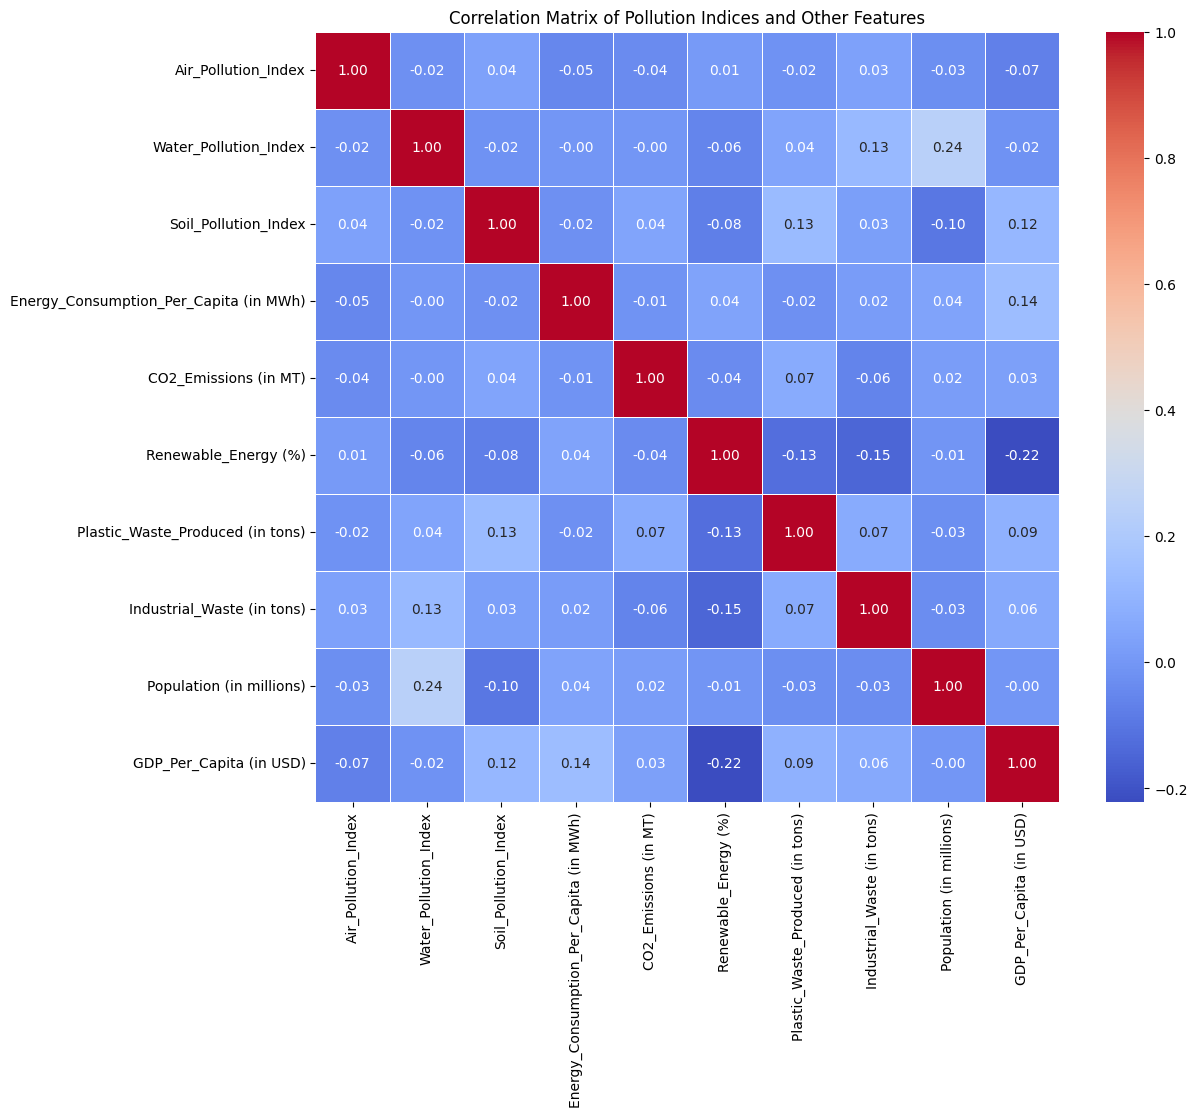

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation_columns = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Energy_Consumption_Per_Capita (in MWh)',
    'CO2_Emissions (in MT)',
    'Renewable_Energy (%)',
    'Plastic_Waste_Produced (in tons)',
    'Industrial_Waste (in tons)',
    'Population (in millions)',
    'GDP_Per_Capita (in USD)'
]
correlation_matrix = df[correlation_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Pollution Indices and Other Features')
plt.show()

In [22]:
df_reloaded = pd.read_csv(path)
print(df_reloaded.head())

        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005               272.70                 124.27   
1     Singapore  2001                86.72                  60.34   
2       Romania  2016                91.59                  83.36   
3  Cook Islands  2018               280.61                  67.16   
4      Djibouti  2008               179.16                 127.53   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                 51.95                    94802.83   
1                117.22                    56283.92   
2                121.72                    56256.02   
3                 93.58                    74864.73   
4                121.55                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44   
2                     4

In [23]:
df_reloaded.fillna(fill_null_values, inplace=True)

In [24]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = MinMaxScaler()
df_reloaded[columns_to_scale] = scaler.fit_transform(df_reloaded[columns_to_scale])

print(df_reloaded.head())

        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005             0.898042               0.553778   
1     Singapore  2001             0.147062               0.173673   
2       Romania  2016             0.166727               0.310542   
3  Cook Islands  2018             0.929982               0.214222   
4      Djibouti  2008             0.520331               0.573161   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0              0.295481                    94802.83   
1              0.768178                    56283.92   
2              0.800768                    56256.02   
3              0.596973                    74864.73   
4              0.799537                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44   
2                     4

In [25]:
mean_air_pollution_by_country = df_reloaded.groupby('Country')['Air_Pollution_Index'].mean().sort_values(ascending=False)
print(mean_air_pollution_by_country.head())

Country
Equatorial Guinea                       1.000000
Saint Barthelemy                        0.996689
French Southern Territories             0.983687
Congo                                   0.977226
United States Minor Outlying Islands    0.971452
Name: Air_Pollution_Index, dtype: float64


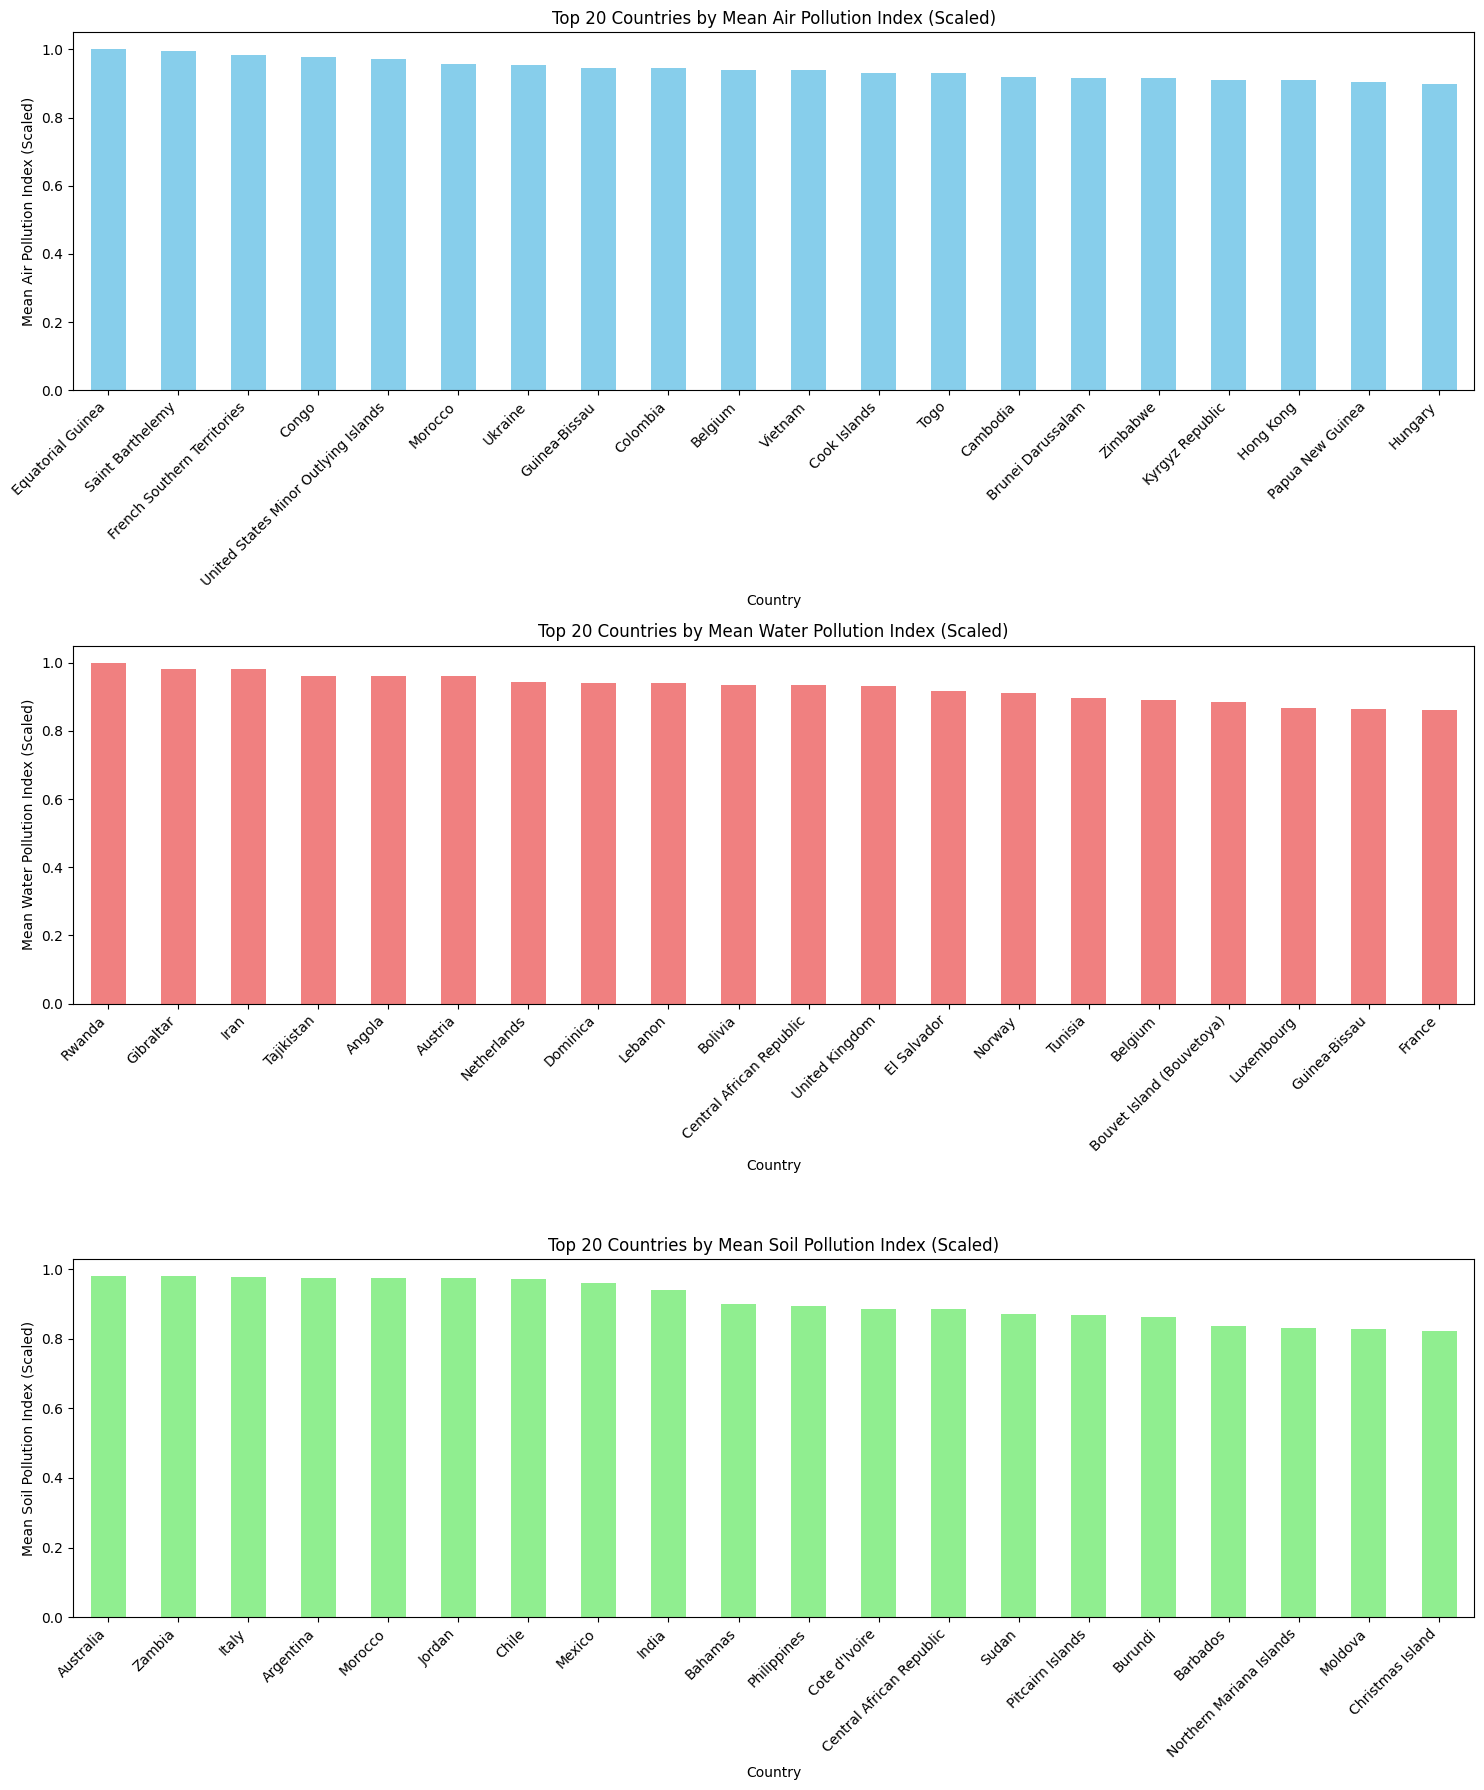

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_air_pollution_by_country = df_reloaded.groupby('Country')['Air_Pollution_Index'].mean().sort_values(ascending=False)
mean_water_pollution_by_country = df_reloaded.groupby('Country')['Water_Pollution_Index'].mean().sort_values(ascending=False)
mean_soil_pollution_by_country = df_reloaded.groupby('Country')['Soil_Pollution_Index'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 18))

plt.subplot(3, 1, 1)
mean_air_pollution_by_country.head(20).plot(kind='bar', color='skyblue')
plt.title('Top 20 Countries by Mean Air Pollution Index (Scaled)')
plt.xlabel('Country')
plt.ylabel('Mean Air Pollution Index (Scaled)')
plt.xticks(rotation=45, ha='right')

plt.subplot(3, 1, 2)
mean_water_pollution_by_country.head(20).plot(kind='bar', color='lightcoral')
plt.title('Top 20 Countries by Mean Water Pollution Index (Scaled)')
plt.xlabel('Country')
plt.ylabel('Mean Water Pollution Index (Scaled)')
plt.xticks(rotation=45, ha='right')

plt.subplot(3, 1, 3)
mean_soil_pollution_by_country.head(20).plot(kind='bar', color='lightgreen')
plt.title('Top 20 Countries by Mean Soil Pollution Index (Scaled)')
plt.xlabel('Country')
plt.ylabel('Mean Soil Pollution Index (Scaled)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

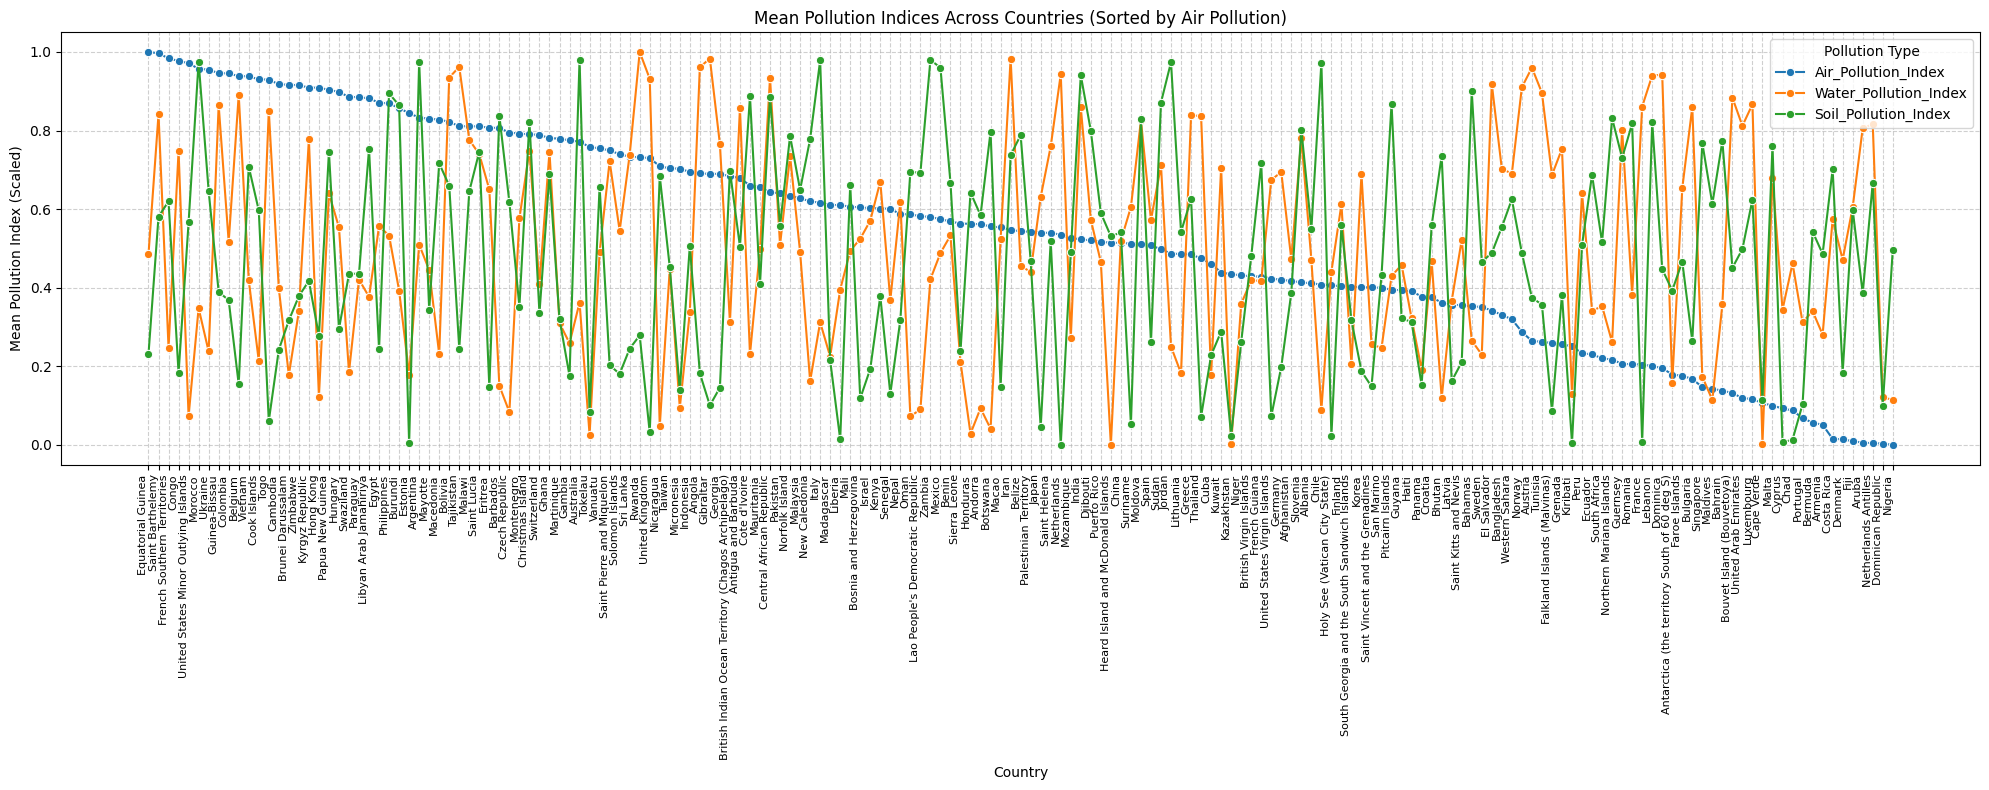

In [27]:
#YEARLY TRENDS
mean_pollution_by_country = df_reloaded.groupby('Country')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()

mean_pollution_by_country_sorted = mean_pollution_by_country.sort_values(by='Air_Pollution_Index', ascending=False)

mean_pollution_melted = mean_pollution_by_country_sorted.melt(
    id_vars=['Country'],
    value_vars=['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index'],
    var_name='Pollution Type',
    value_name='Mean Pollution Index'
)

plt.figure(figsize=(20, 8))
sns.lineplot(data=mean_pollution_melted, x='Country', y='Mean Pollution Index', hue='Pollution Type', marker='o')
plt.title('Mean Pollution Indices Across Countries (Sorted by Air Pollution)')
plt.xlabel('Country')
plt.ylabel('Mean Pollution Index (Scaled)')
plt.xticks(rotation=90, ha='right', fontsize=8) # Rotate labels for readability
plt.legend(title='Pollution Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Reinitialize df_reloaded to ensure consistency with previous steps
df_reloaded = pd.read_csv(path)
df_reloaded['Year'] = pd.to_datetime(df_reloaded['Year'], format='%Y')

df_raw.fillna(fill_null_values, inplace=True)

# Apply Min-Max scaling to pollution indices as in previous steps
columns_to_scale = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = MinMaxScaler()
df_reloaded[columns_to_scale] = scaler.fit_transform(df_reloaded[columns_to_scale])

# Calculate and merge YoY growth rates as in previous steps
df_raw_temp = pd.read_csv(path) # Use a temporary df_raw to avoid conflicts
df_raw_temp['Year'] = pd.to_datetime(df_raw_temp['Year'], format='%Y')
df_raw_temp = df_raw_temp.sort_values(by=['Country', 'Year'])

pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']
for col in pollution_columns:
    df_raw_temp[f'{col}_YoY_Growth'] = df_raw_temp.groupby('Country')[col].pct_change() * 100

growth_columns_actual = [f'{col}_YoY_Growth' for col in pollution_columns]

df_reloaded = pd.merge(
    df_reloaded,
    df_raw_temp[['Country', 'Year'] + growth_columns_actual],
    on=['Country', 'Year'],
    how='left'
)

# Fill NaNs in growth columns with 0 as in previous steps
for col in growth_columns_actual:
    if col in df_reloaded.columns:
        df_reloaded[col] = df_reloaded[col].fillna(0)

# 1. Identify all numerical columns that might contain missing values
# Exclude 'Country' (object) and 'Year' (datetime) from numerical imputation
numerical_columns = df_reloaded.select_dtypes(include=['number']).columns.tolist()

# 2. Sort by Country and Year for correct country-specific fill operations
df_reloaded.sort_values(by=['Country', 'Year'], inplace=True)

# 3. Group by 'Country' and apply forward-fill (ffill)
df_reloaded[numerical_columns] = df_reloaded.groupby('Country')[numerical_columns].ffill()

# 4. Group by 'Country' and apply backward-fill (bfill)
df_reloaded[numerical_columns] = df_reloaded.groupby('Country')[numerical_columns].bfill()

# 5. For any remaining NaN values (e.g., if a country had all NaNs for a column),
#    calculate the global mean for each numerical column and fill.
global_means = df_reloaded[numerical_columns].mean()
df_reloaded[numerical_columns] = df_reloaded[numerical_columns].fillna(global_means)

print("Missing values after structured imputation:")
print(df_reloaded[numerical_columns].isnull().sum().sum())
print(df_reloaded.head())


Missing values after structured imputation:
0
         Country       Year  Air_Pollution_Index  Water_Pollution_Index  \
120  Afghanistan 2002-01-01             0.613608               0.640763   
190  Afghanistan 2006-01-01             0.221280               0.304477   
78       Albania 2006-01-01             0.411508               0.471372   
90       Andorra 2005-01-01             0.561639               0.093347   
24        Angola 2016-01-01             0.690894               0.961591   

     Soil_Pollution_Index  Industrial_Waste (in tons)  \
120              0.245872                    43576.51   
190              0.528027                    20688.64   
78               0.548885                    93094.36   
90               0.584516                    33356.33   
24               0.182286                    33021.64   

     Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
120                     150.10                   9.58                 34.61   
19

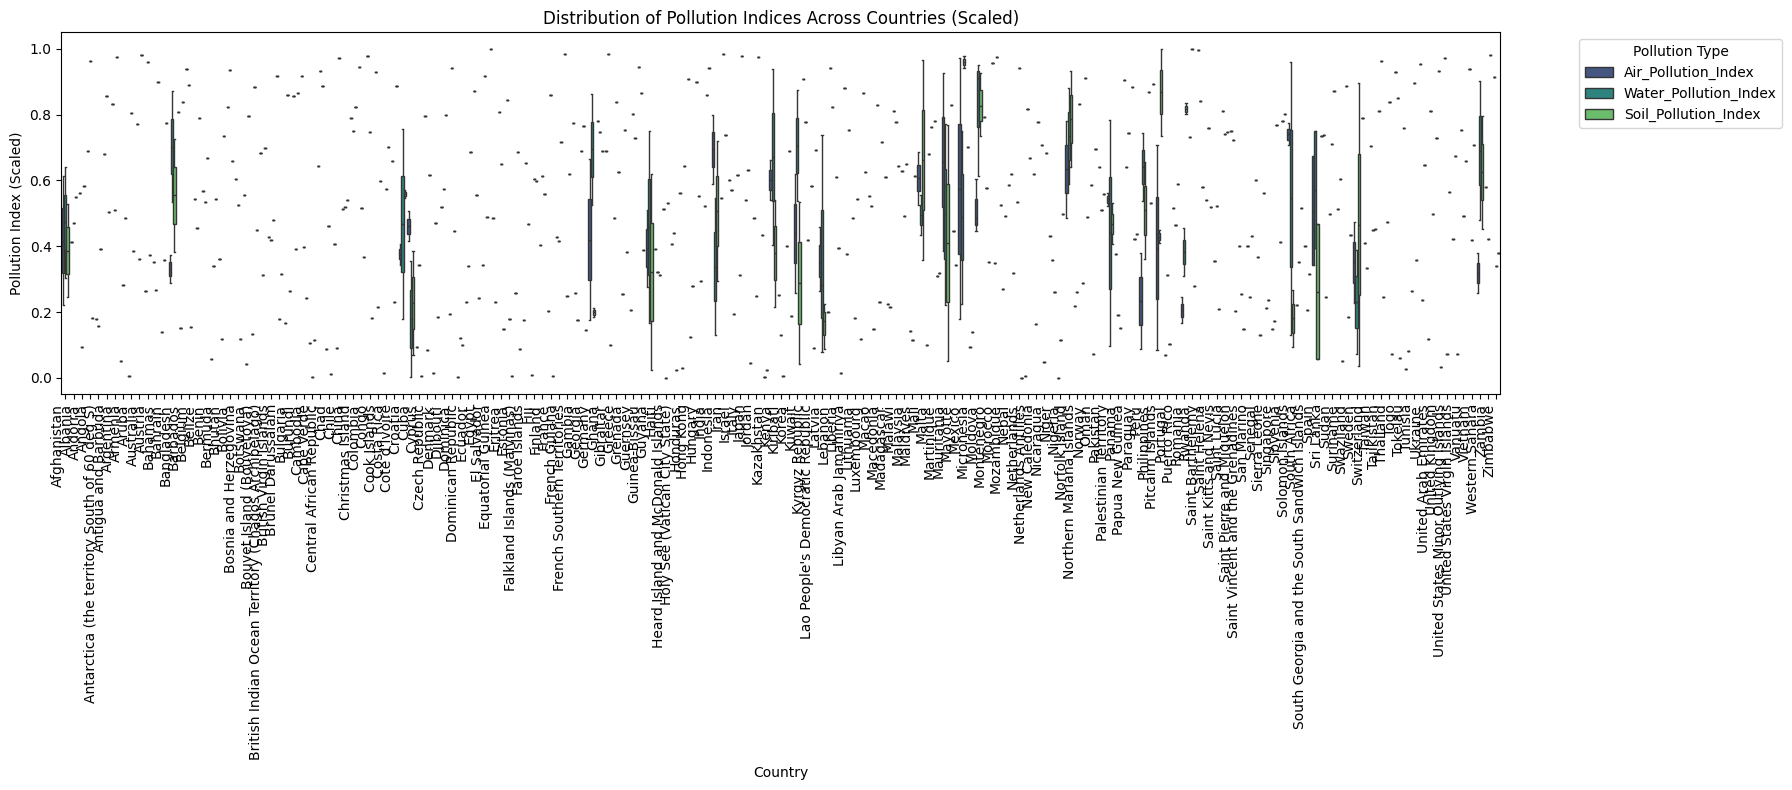

In [29]:
pollution_indices = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']

df_melted = df_reloaded.melt(id_vars=['Country'], value_vars=pollution_indices, var_name='Pollution Type', value_name='Pollution Index')

plt.figure(figsize=(18, 8))
sns.boxplot(data=df_melted, x='Country', y='Pollution Index', hue='Pollution Type', palette='viridis')
plt.title('Distribution of Pollution Indices Across Countries (Scaled)')
plt.xlabel('Country')
plt.ylabel('Pollution Index (Scaled)')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Pollution Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

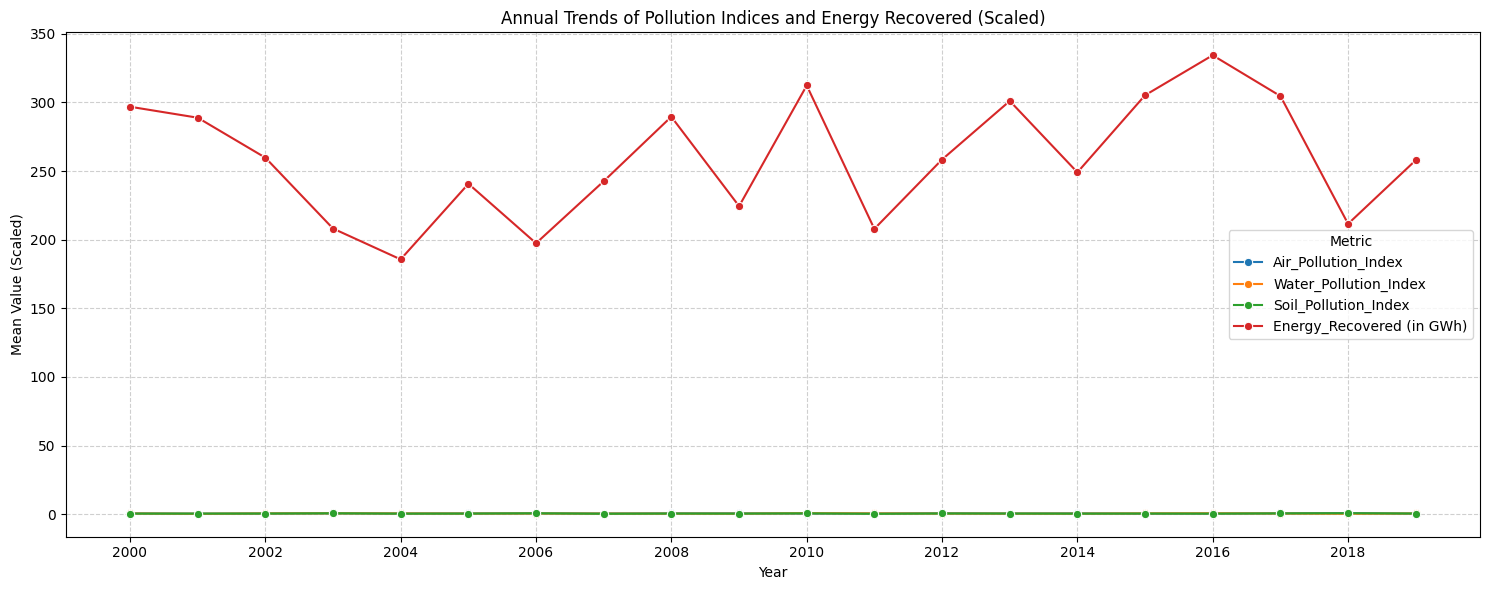

In [30]:
annual_pollution_trends = df_reloaded.groupby('Year')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Recovered (in GWh)']].mean().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=annual_pollution_trends.melt(id_vars=['Year'], var_name='Metric', value_name='Mean Value'), x='Year', y='Mean Value', hue='Metric', marker='o')
plt.title('Annual Trends of Pollution Indices and Energy Recovered (Scaled)')
plt.xlabel('Year')
plt.ylabel('Mean Value (Scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [36]:
#ENERGY RECOVERD
from sklearn.model_selection import train_test_split

# Ensure 'Year' is a datetime object and create 'Year_Numeric' for consistency
# This also ensures df_reloaded is sorted before creating lag features
df_reloaded['Year'] = pd.to_datetime(df_reloaded['Year'], format='%Y')
df_reloaded['Year_Numeric'] = df_reloaded['Year'].dt.year
df_reloaded.sort_values(by=['Country', 'Year_Numeric'], inplace=True)

# Re-create lag features as df_reloaded was reloaded
df_reloaded['Air_Pollution_Index_Lag1'] = df_reloaded.groupby('Country')['Air_Pollution_Index'].shift(1)
df_reloaded['CO2_Emissions_Lag1'] = df_reloaded.groupby('Country')['CO2_Emissions (in MT)'].shift(1)

# Handle NaNs introduced by lag features specifically (if not already handled by ffill/bfill in f4e3b606)
# Since f4e3b606 already has a robust NaN handling, this might be redundant, but safe to ensure.
# For lag features, filling with 0 or the mean of the original column can be options
# Given the earlier comprehensive NaN handling in cell f4e3b606, these should be taken care of.

# 1. Define the target variable y_model
y_model = df_reloaded['Energy_Recovered (in GWh)']

# Remove the redundant fillna call, as f4e3b606 handles missing values comprehensively
# df_reloaded.fillna(fill_null_values, inplace=True)

# 2. Create a list of feature columns, X_features
# Removed 'Energy_Recovery_Efficiency' as it's not defined anywhere in the notebook
X_features = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Year_Numeric',
    'Air_Pollution_Index_Lag1',
    'CO2_Emissions_Lag1',
    'CO2_Emissions (in MT)',
    'Industrial_Waste (in tons)',
    'Renewable_Energy (%)',
    'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Population (in millions)',
    'GDP_Per_Capita (in USD)'
] + growth_columns_actual # Add all YoY growth rate columns

# 3. Create the feature DataFrame X_model
# Verify all X_features exist in df_reloaded before selecting
missing_features = [col for col in X_features if col not in df_reloaded.columns]
if missing_features:
    print(f"Error: The following features are missing from df_reloaded: {missing_features}")
    # Decide how to handle: raise error, remove from X_features, or create dummy
    # For now, we'll assume the above steps to re-create Year_Numeric and lag features solve it.
    # If Energy_Recovery_Efficiency was intended, it needs to be created.

X_model = df_reloaded[X_features]

# 4. Verify that there are no missing values in X_model and y_model
print("Missing values in X_model after feature selection:")
print(X_model.isnull().sum().sum())
print("Missing values in y_model:")
print(y_model.isnull().sum())

# Ensure no NaNs remain before splitting, drop rows if any (should be 0 based on previous steps)
# The NaN handling in f4e3b606 should have addressed this.
# This conditional block remains as a safeguard but should ideally not execute if previous steps are correct.
if X_model.isnull().sum().sum() > 0 or y_model.isnull().sum() > 0:
    print("Warning: Dropping rows with remaining NaN values in X_model or y_model.")
    # Combine X and y to drop rows consistently
    data_for_split = pd.concat([X_model, y_model], axis=1).dropna()
    X_model = data_for_split[X_features]
    y_model = data_for_split['Energy_Recovered (in GWh)']
    print("Missing values in X_model after dropping NaNs:")
    print(X_model.isnull().sum().sum())
    print("Missing values in y_model after dropping NaNs:")
    print(y_model.isnull().sum())

# 5. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

print("\nData splitting complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Missing values in X_model after feature selection:
350
Missing values in y_model:
0
Missing values in X_model after dropping NaNs:
0
Missing values in y_model after dropping NaNs:
0

Data splitting complete:
X_train shape: (21, 18)
X_test shape: (6, 18)
y_train shape: (21,)
y_test shape: (6,)


In [45]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import numpy as np
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# --- Start of added code to define X, y_encoded, le ---
# Re-create df_countries_pollution from df_reloaded (as defined in efb7cb52)
df_countries_pollution = df_reloaded.groupby('Country')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()

# Calculate Overall_Pollution_Score and Pollution_Severity (as defined in 6de296bc)
df_countries_pollution['Overall_Pollution_Score'] = df_countries_pollution[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean(axis=1)
low_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.33)
medium_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.66)
def categorize_pollution(score):
    if score <= low_threshold:
        return 'Low'
    elif score <= medium_threshold:
        return 'Medium'
    else:
        return 'High'
df_countries_pollution['Pollution_Severity'] = df_countries_pollution['Overall_Pollution_Score'].apply(categorize_pollution)

# Create df_countries_pollution_merged, X, y, y_encoded, le (as defined in 99a83dea)
df_countries_pollution_merged = df_countries_pollution.merge(
    df_reloaded.groupby('Country')['CO2_Emissions (in MT)'].mean().reset_index(),
    on='Country',
    how='left'
)

X = df_countries_pollution_merged[['Air_Pollution_Index', 'CO2_Emissions (in MT)']].dropna() # Dropna to handle potential NaNs after merge
y = df_countries_pollution_merged['Pollution_Severity'].loc[X.index] # Align y with X after dropping NaNs

le = LabelEncoder()
y_encoded = le.fit_transform(y)
# --- End of added code ---


# 1. Initialize KFold with 5 splits, shuffle, and a random state
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Create empty lists to store metrics for each fold
accuracy_scores_lr = []
precision_scores_lr = []
recall_scores_lr = []
f1_scores_lr = []
auc_scores_lr = [] # List to store average AUC per fold

# 3. Loop through each fold
for train_index, val_index in kf.split(X):
    # a. Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y_encoded[train_index], y_encoded[val_index]

    # b. Initialize and train a LogisticRegression model
    model = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr') # Specify multi_class for AUC
    model.fit(X_train_fold, y_train_fold)

    # c. Make predictions and get probabilities on the validation data
    y_pred_fold = model.predict(X_val_fold)
    y_prob_fold = model.predict_proba(X_val_fold)

    # d. Calculate metrics for the current fold
    accuracy_scores_lr.append(accuracy_score(y_val_fold, y_pred_fold))
    precision_scores_lr.append(precision_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))
    recall_scores_lr.append(recall_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))
    f1_scores_lr.append(f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))

    # Calculate AUC for each class (One-vs-Rest) for the current fold
    fold_roc_auc_values = []
    for i in range(len(le.classes_)):
        # Check if the class is present in y_val_fold to avoid errors with roc_curve
        if i in y_val_fold:
            fpr_i, tpr_i, _ = roc_curve(y_val_fold == i, y_prob_fold[:, i])
            fold_roc_auc_values.append(auc(fpr_i, tpr_i))
        else:
            # If a class is not present in the validation fold, its AUC cannot be calculated
            # We can skip it or assign a default value like 0.5 (random)
            fold_roc_auc_values.append(0.5)
    auc_scores_lr.append(np.mean(fold_roc_auc_values))

# 4. Calculate and print the average metrics across all folds
print(f"Average Accuracy across folds: {np.mean(accuracy_scores_lr):.2f}")
print(f"Average Precision across folds: {np.mean(precision_scores_lr):.2f}")
print(f"Average Recall across folds: {np.mean(recall_scores_lr):.2f}")
print(f"Average F1-score across folds: {np.mean(f1_scores_lr):.2f}")
print(f"Average AUC across folds: {np.mean(auc_scores_lr):.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Average Accuracy across folds: 0.45
Average Precision across folds: 0.54
Average Recall across folds: 0.45
Average F1-score across folds: 0.43
Average AUC across folds: 0.71


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [34]:
print('Head of Energy_Consumption_Per_Capita (in MWh) column:')
print(df_reloaded['Energy_Consumption_Per_Capita (in MWh)'].head())

print('\nDescriptive Statistics for Energy_Consumption_Per_Capita (in MWh):')
print(df_reloaded['Energy_Consumption_Per_Capita (in MWh)'].describe())

Head of Energy_Consumption_Per_Capita (in MWh) column:
120     9.43
190    12.72
78      2.70
90     17.86
24      6.77
Name: Energy_Consumption_Per_Capita (in MWh), dtype: float64

Descriptive Statistics for Energy_Consumption_Per_Capita (in MWh):
count    202.00000
mean       9.39302
std        5.58119
min        0.53000
25%        4.56750
50%        9.22500
75%       13.98500
max       19.98000
Name: Energy_Consumption_Per_Capita (in MWh), dtype: float64


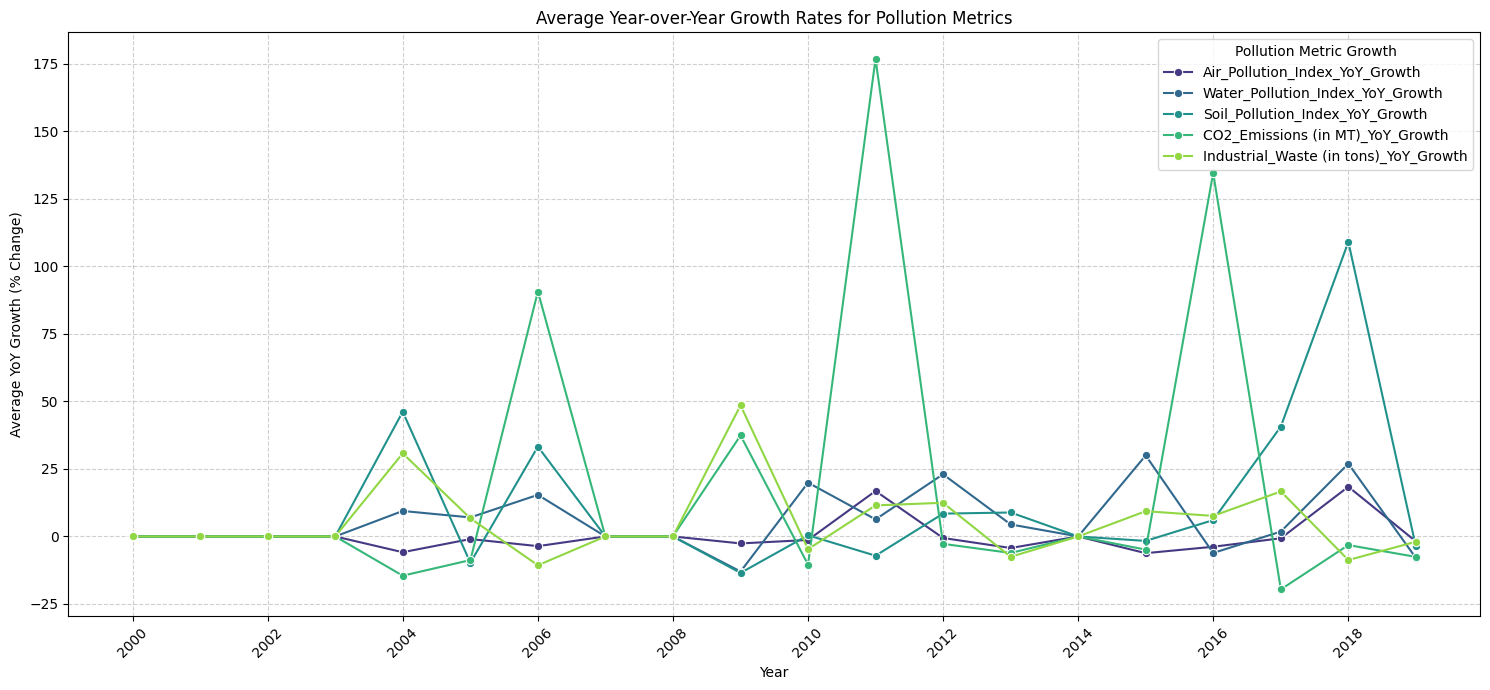


--- Enhanced Linear Regression Model Performance (with YoY Growth Features) ---
Mean Squared Error (MSE): 28857.030161507097
Mean Absolute Error (MAE): 147.56702433480294
R-squared (R2): -0.10833737963188939
Coefficients: [-2.53286344e+01 -7.60857917e-01 -5.77047152e-04  6.29429537e-01
 -5.07875026e-02  9.33025691e-02  1.49121997e-01 -8.86952743e-02]
Intercept: 319.01713520752713

--- Summary of Insights Gained from Time-Trend Features ---
Integrating Year-over-Year (YoY) growth rates as features provides several benefits:
1. Captures Dynamics: These features allow the model to capture temporal dynamics and trends in pollution and waste metrics, rather than just static values.
2. Improved Predictive Power: By understanding how these metrics are changing over time, the model can potentially make more accurate predictions for 'Energy_Recovered (in GWh)' or other target variables.
3. Economic and Environmental Impact: Growth rates can reflect underlying economic changes (e.g., industrial

In [35]:
#YOY GROWTH
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


df_reloaded = pd.read_csv(path)
df_reloaded['Year'] = pd.to_datetime(df_reloaded['Year'], format='%Y')

df_raw.fillna(fill_null_values, inplace=True)

columns_to_scale = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
scaler = MinMaxScaler()
df_reloaded[columns_to_scale] = scaler.fit_transform(df_reloaded[columns_to_scale])


df_raw = pd.read_csv(path)
df_raw['Year'] = pd.to_datetime(df_raw['Year'], format='%Y')
df_raw = df_raw.sort_values(by=['Country', 'Year'])

pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']

for col in pollution_columns:
    df_raw[f'{col}_YoY_Growth'] = df_raw.groupby('Country')[col].pct_change() * 100


growth_columns_actual = [f'{col}_YoY_Growth' for col in pollution_columns]


df_reloaded = pd.merge(
    df_reloaded,
    df_raw[['Country', 'Year'] + growth_columns_actual],
    on=['Country', 'Year'],
    how='left'
)


for col in growth_columns_actual:
    if col in df_reloaded.columns:
        df_reloaded[col] = df_reloaded[col].fillna(0)
    else:
        print(f"Warning: Column '{col}' not found in df_reloaded. This might indicate an issue with the merge step.")


avg_growth_rates_annual = df_reloaded.groupby('Year')[growth_columns_actual].mean().reset_index()

avg_growth_rates_melted = avg_growth_rates_annual.melt(
    id_vars=['Year'],
    value_vars=growth_columns_actual,
    var_name='Pollution Metric Growth',
    value_name='Average YoY Growth (% Change)'
)

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=avg_growth_rates_melted,
    x='Year',
    y='Average YoY Growth (% Change)',
    hue='Pollution Metric Growth',
    marker='o',
    palette='viridis'
)
plt.title('Average Year-over-Year Growth Rates for Pollution Metrics')
plt.xlabel('Year')
plt.ylabel('Average YoY Growth (% Change)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


y_model = df_reloaded['Energy_Recovered (in GWh)']


existing_features = ['Air_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']
new_trend_features = growth_columns_actual
all_features = existing_features + new_trend_features

# Filter df_reloaded to include only these columns and the target for the model
df_model_enhanced = df_reloaded[all_features + ['Energy_Recovered (in GWh)']].copy()

# Drop rows with any remaining NaNs in the features or target for model training
df_model_enhanced.dropna(inplace=True)

X_enhanced = df_model_enhanced[all_features]
y_enhanced = df_model_enhanced['Energy_Recovered (in GWh)']

# Split the data into training and testing sets
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(X_enhanced, y_enhanced, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_enhanced = LinearRegression()
model_enhanced.fit(X_train_enhanced, y_train_enhanced)

# Make predictions on the test set
y_pred_enhanced = model_enhanced.predict(X_test_enhanced)

# Evaluate the model
mse_enhanced = mean_squared_error(y_test_enhanced, y_pred_enhanced)
mae_enhanced = mean_absolute_error(y_test_enhanced, y_pred_enhanced)
r2_enhanced = r2_score(y_test_enhanced, y_pred_enhanced)

print("\n--- Enhanced Linear Regression Model Performance (with YoY Growth Features) ---")
print(f'Mean Squared Error (MSE): {mse_enhanced}')
print(f'Mean Absolute Error (MAE): {mae_enhanced}')
print(f'R-squared (R2): {r2_enhanced}')
print('Coefficients:', model_enhanced.coef_)
print('Intercept:', model_enhanced.intercept_)

print("\n--- Summary of Insights Gained from Time-Trend Features ---")
print("Integrating Year-over-Year (YoY) growth rates as features provides several benefits:")
print("1. Captures Dynamics: These features allow the model to capture temporal dynamics and trends in pollution and waste metrics, rather than just static values.")
print("2. Improved Predictive Power: By understanding how these metrics are changing over time, the model can potentially make more accurate predictions for 'Energy_Recovered (in GWh)' or other target variables.")
print("3. Economic and Environmental Impact: Growth rates can reflect underlying economic changes (e.g., industrial output growth) or environmental policy effectiveness. For instance, a negative growth in CO2 emissions indicates improvement.")
print("4. Feature Engineering: It demonstrates a practical application of feature engineering, creating more informative variables from existing data.")
print("5. Contextual Understanding: Analysts can gain deeper insights into the factors influencing the target variable by observing the coefficients of the growth rate features. For example, a positive coefficient for 'Industrial_Waste (in tons)_YoY_Growth' might indicate that a growing industrial waste problem is linked to higher energy recovery (perhaps due to waste-to-energy initiatives) or vice-versa.")

In [38]:
df_countries_pollution = df_reloaded.groupby('Country')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()
df_countries_pollution['Overall_Pollution_Score'] = df_countries_pollution[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean(axis=1)

print(df_countries_pollution.head())

                                        Country  Air_Pollution_Index  \
0                                   Afghanistan             0.417444   
1                                       Albania             0.411508   
2                                       Andorra             0.561639   
3                                        Angola             0.690894   
4  Antarctica (the territory South of 60 deg S)             0.179205   

   Water_Pollution_Index  Soil_Pollution_Index  Overall_Pollution_Score  
0               0.472620              0.386950                 0.425671  
1               0.471372              0.548885                 0.477255  
2               0.093347              0.584516                 0.413167  
3               0.961591              0.182286                 0.611590  
4               0.158392              0.392961                 0.243519  


In [39]:
#LG REG MODEL1
low_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.33)
medium_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.66)

def categorize_pollution(score):
    if score <= low_threshold:
        return 'Low'
    elif score <= medium_threshold:
        return 'Medium'
    else:
        return 'High'

df_countries_pollution['Pollution_Severity'] = df_countries_pollution['Overall_Pollution_Score'].apply(categorize_pollution)

print(df_countries_pollution.head())

                                        Country  Air_Pollution_Index  \
0                                   Afghanistan             0.417444   
1                                       Albania             0.411508   
2                                       Andorra             0.561639   
3                                        Angola             0.690894   
4  Antarctica (the territory South of 60 deg S)             0.179205   

   Water_Pollution_Index  Soil_Pollution_Index  Overall_Pollution_Score  \
0               0.472620              0.386950                 0.425671   
1               0.471372              0.548885                 0.477255   
2               0.093347              0.584516                 0.413167   
3               0.961591              0.182286                 0.611590   
4               0.158392              0.392961                 0.243519   

  Pollution_Severity  
0                Low  
1             Medium  
2                Low  
3               High  
4

In [47]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-create df_countries_pollution (from cell efb7cb52)
df_countries_pollution = df_reloaded.groupby('Country')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()
df_countries_pollution['Overall_Pollution_Score'] = df_countries_pollution[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean(axis=1)

# Re-define Pollution_Severity and thresholds (from cell 6de296bc)
low_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.33)
medium_threshold = df_countries_pollution['Overall_Pollution_Score'].quantile(0.66)
def categorize_pollution(score):
    if score <= low_threshold:
        return 'Low'
    elif score <= medium_threshold:
        return 'Medium'
    else:
        return 'High'
df_countries_pollution['Pollution_Severity'] = df_countries_pollution['Overall_Pollution_Score'].apply(categorize_pollution)

# Re-create X, y, y_encoded, le (from cell 99a83dea)
df_countries_pollution_merged = df_countries_pollution.merge(
    df_reloaded.groupby('Country')['CO2_Emissions (in MT)'].mean().reset_index(),
    on='Country',
    how='left'
)
X = df_countries_pollution_merged[['Air_Pollution_Index', 'CO2_Emissions (in MT)']].dropna()
y = df_countries_pollution_merged['Pollution_Severity'].loc[X.index]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Re-train a Logistic Regression model on the full dataset for coefficient interpretation
final_logistic_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr') # Specify multi_class for consistency with KFold
final_logistic_model.fit(X, y_encoded)

# The coefficients for Logistic Regression are for each class vs. the rest (multinomial) or one-vs-rest (OvR)
# For simplicity, we'll look at the coefficients for each feature across classes if available (OvR strategy is default for multiclass)
# If it's multinomial, it will be one-vs-rest for each class.

# Coefficients are typically stored as a 2D array (n_classes, n_features).
# We'll print them for each class.

print("Logistic Regression Coefficients per Class:")
for i, class_label in enumerate(le.classes_):
    print(f"\nCoefficients for class '{class_label}' (mapped to {i}):")
    coefficients = pd.Series(final_logistic_model.coef_[i], index=X.columns)
    # Sort coefficients by their absolute values for importance within this class
    sorted_coefficients = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)
    print(sorted_coefficients)

print("\nClasses learned by LabelEncoder:", le.classes_)

Logistic Regression Coefficients per Class:

Coefficients for class 'High' (mapped to 0):
Air_Pollution_Index      3.320841
CO2_Emissions (in MT)    0.016902
dtype: float64

Coefficients for class 'Low' (mapped to 1):
Air_Pollution_Index     -2.843376
CO2_Emissions (in MT)    0.010244
dtype: float64

Coefficients for class 'Medium' (mapped to 2):
Air_Pollution_Index     -0.334369
CO2_Emissions (in MT)   -0.023643
dtype: float64

Classes learned by LabelEncoder: ['High' 'Low' 'Medium']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.49

Classification Report:
               precision    recall  f1-score   support

        High       0.68      0.59      0.63        22
         Low       0.40      0.40      0.40        15
      Medium       0.37      0.44      0.40        16

    accuracy                           0.49        53
   macro avg       0.48      0.48      0.48        53
weighted avg       0.51      0.49      0.50        53



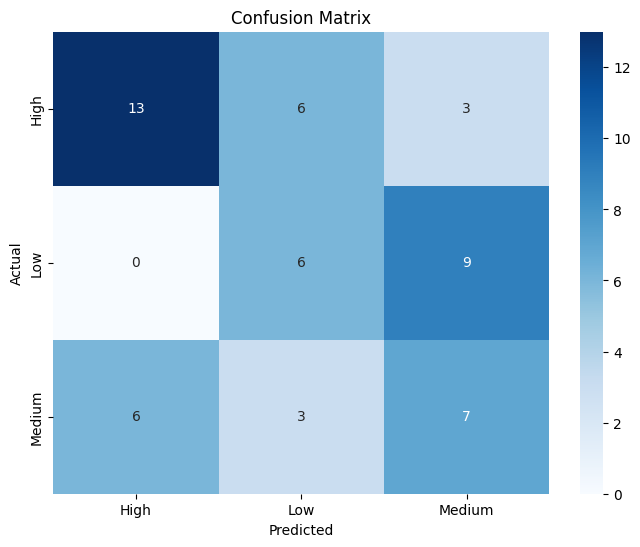

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
df_countries_pollution_merged = df_countries_pollution.merge(
    df_reloaded.groupby('Country')['CO2_Emissions (in MT)'].mean().reset_index(),
    on='Country',
    how='left'
)

X = df_countries_pollution_merged[['Air_Pollution_Index', 'CO2_Emissions (in MT)']]
y = df_countries_pollution_merged['Pollution_Severity']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:\n', report)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [42]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Initialize KFold with 5 splits, shuffle, and a random state
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Create empty lists to store metrics for each fold
mse_scores = []
mae_scores = []
r2_scores = []

# 3. Loop through each fold
for train_index, val_index in kf.split(X_model):
    # a. Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_model.iloc[train_index], X_model.iloc[val_index]
    y_train_fold, y_val_fold = y_model.iloc[train_index], y_model.iloc[val_index]

    # b. Initialize and train a LinearRegression model
    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)

    # c. Make predictions on the validation data
    y_pred_fold = model.predict(X_val_fold)

    # d. Calculate metrics for the current fold
    mse = mean_squared_error(y_val_fold, y_pred_fold)
    mae = mean_absolute_error(y_val_fold, y_pred_fold)
    r2 = r2_score(y_val_fold, y_pred_fold)

    # e. Append these metrics to their respective lists
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)

# 4. Calculate and print the average metrics across all folds
print(f"Average MSE across folds: {np.mean(mse_scores):.2f}")
print(f"Average MAE across folds: {np.mean(mae_scores):.2f}")
print(f"Average R2 across folds: {np.mean(r2_scores):.2f}")

Average MSE across folds: 132202.52
Average MAE across folds: 284.23
Average R2 across folds: -15.30


In [43]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Re-train a Linear Regression model on the full dataset for coefficient interpretation
final_model = LinearRegression()
final_model.fit(X_model, y_model)

# Create a Series to map feature names to their coefficients
feature_coefficients = pd.Series(final_model.coef_, index=X_model.columns)

# Sort coefficients by their absolute values to identify importance
sorted_coefficients = feature_coefficients.reindex(feature_coefficients.abs().sort_values(ascending=False).index)

print("Sorted Feature Coefficients (Absolute Importance):")
print(sorted_coefficients)

Sorted Feature Coefficients (Absolute Importance):
Air_Pollution_Index                      -804.654703
Air_Pollution_Index_Lag1                  189.411901
Water_Pollution_Index                     169.751055
Soil_Pollution_Index                       97.722564
Year_Numeric                                6.549804
Energy_Consumption_Per_Capita (in MWh)     -4.634216
Air_Pollution_Index_YoY_Growth              3.665960
CO2_Emissions (in MT)                       3.050477
Renewable_Energy (%)                       -2.841557
CO2_Emissions_Lag1                          2.768090
Population (in millions)                    1.107464
Industrial_Waste (in tons)_YoY_Growth       0.758954
Water_Pollution_Index_YoY_Growth            0.162431
Soil_Pollution_Index_YoY_Growth             0.143377
CO2_Emissions (in MT)_YoY_Growth            0.048207
Plastic_Waste_Produced (in tons)            0.002169
GDP_Per_Capita (in USD)                    -0.002030
Industrial_Waste (in tons)                 -0.00

/tmp/ipykernel_622/3006389308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pollution_severity_counts.index, y=pollution_severity_counts.values, palette='viridis')


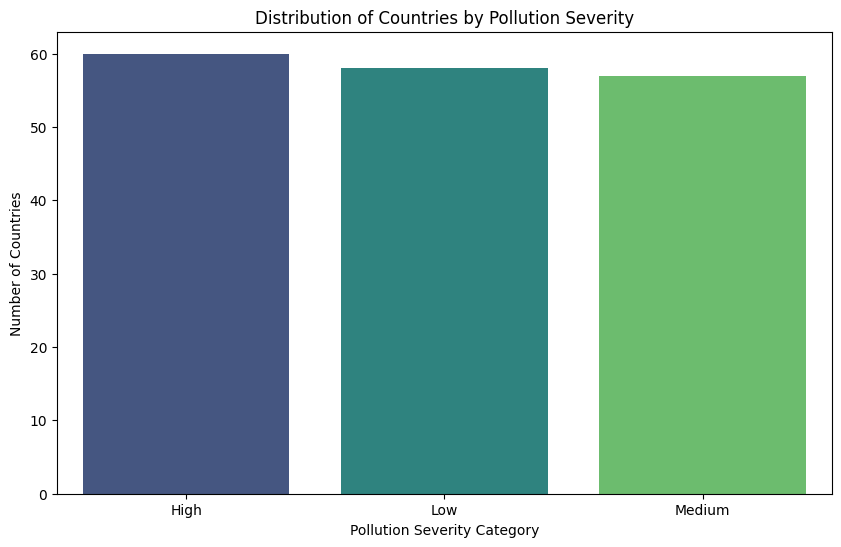

In [44]:
pollution_severity_counts = df_countries_pollution['Pollution_Severity'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=pollution_severity_counts.index, y=pollution_severity_counts.values, palette='viridis')
plt.title('Distribution of Countries by Pollution Severity')
plt.xlabel('Pollution Severity Category')
plt.ylabel('Number of Countries')
plt.show()

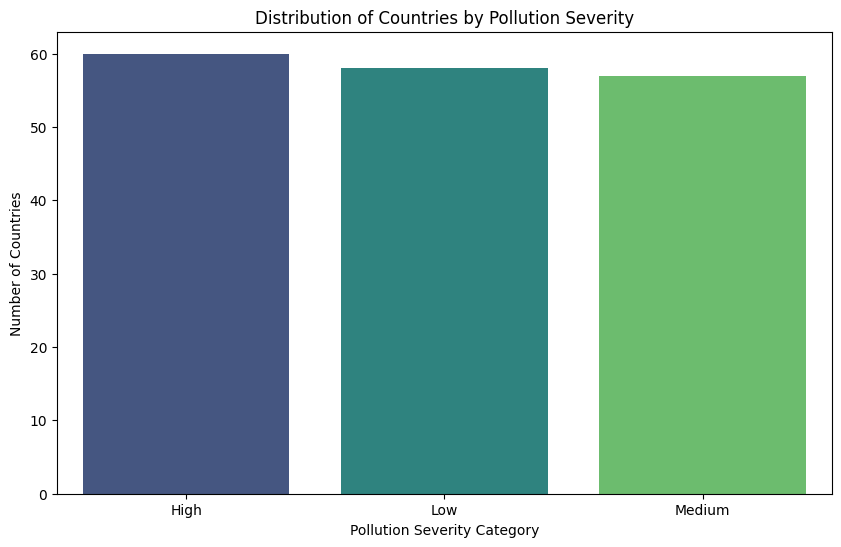

In [46]:
pollution_severity_counts = df_countries_pollution['Pollution_Severity'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=pollution_severity_counts.index, y=pollution_severity_counts.values, hue=pollution_severity_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Countries by Pollution Severity')
plt.xlabel('Pollution Severity Category')
plt.ylabel('Number of Countries')
plt.show()

In [48]:
from sklearn.model_selection import train_test_split

# Perform the train-test split
X_train_roc, X_test_roc, y_train_roc, y_test_roc = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Shape of X_train_roc: {X_train_roc.shape}")
print(f"Shape of X_test_roc: {X_test_roc.shape}")
print(f"Shape of y_train_roc: {y_train_roc.shape}")
print(f"Shape of y_test_roc: {y_test_roc.shape}")

Shape of X_train_roc: (122, 2)
Shape of X_test_roc: (53, 2)
Shape of y_train_roc: (122,)
Shape of y_test_roc: (53,)


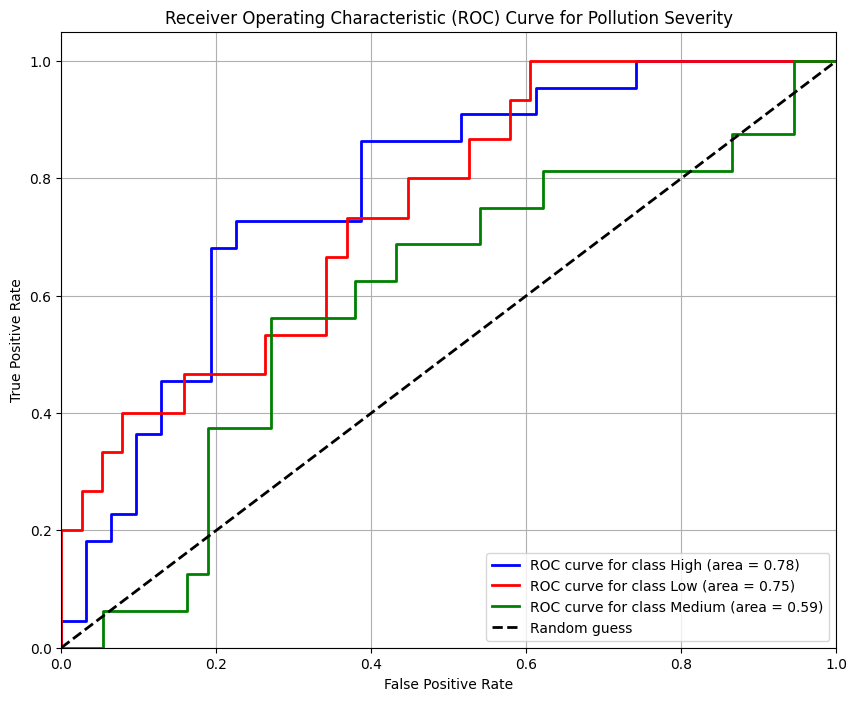

AUC scores per class:
  Class 'High': 0.78
  Class 'Low': 0.75
  Class 'Medium': 0.59

Interpretation:
The ROC curves visually represent the trade-off between the true positive rate and false positive rate for different classification thresholds for each pollution severity category. A curve that bows towards the top-left corner indicates better performance. The area under the curve (AUC) quantifies the model's ability to distinguish between the classes.
An AUC score of 1.0 indicates a perfect classifier, while an AUC of 0.5 suggests performance no better than random guessing.
By examining the individual AUC scores, we can determine how well the Logistic Regression model differentiates each pollution severity category from the others. For example, a higher AUC for 'High' pollution means the model is good at identifying countries with high pollution severity.


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Train the Logistic Regression model
# Use the same parameters as the previous Logistic Regression model for consistency
model_roc = LogisticRegression(max_iter=1000, random_state=42)
model_roc.fit(X_train_roc, y_train_roc)

# 2. Predict probabilities on the test set
y_pred_proba_roc = model_roc.predict_proba(X_test_roc)

# 3. Calculate ROC curve and AUC for each class
n_classes = len(le.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()
colors = ['blue', 'red', 'green'] # Define colors for each class

plt.figure(figsize=(10, 8))
for i, class_label in enumerate(le.classes_):
    fpr[i], tpr[i], _ = roc_curve(y_test_roc, y_pred_proba_roc[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'ROC curve for class {class_label} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Pollution Severity')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("AUC scores per class:")
for i, class_label in enumerate(le.classes_):
    print(f"  Class '{class_label}': {roc_auc[i]:.2f}")

print("\nInterpretation:")
print("The ROC curves visually represent the trade-off between the true positive rate and false positive rate for different classification thresholds for each pollution severity category. A curve that bows towards the top-left corner indicates better performance. The area under the curve (AUC) quantifies the model's ability to distinguish between the classes.")
print("An AUC score of 1.0 indicates a perfect classifier, while an AUC of 0.5 suggests performance no better than random guessing.")
print("By examining the individual AUC scores, we can determine how well the Logistic Regression model differentiates each pollution severity category from the others. For example, a higher AUC for 'High' pollution means the model is good at identifying countries with high pollution severity.")

In [50]:
from sklearn.preprocessing import LabelEncoder

# 1. Calculate the Overall_Pollution_Score for each row in the df_reloaded DataFrame
df_reloaded['Overall_Pollution_Score'] = df_reloaded[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean(axis=1)

# 2. Determine low_threshold and medium_threshold for pollution severity
low_threshold = df_reloaded['Overall_Pollution_Score'].quantile(0.33)
medium_threshold = df_reloaded['Overall_Pollution_Score'].quantile(0.66)

# 3. Define a function categorize_pollution and apply it
def categorize_pollution(score):
    if score <= low_threshold:
        return 'Low'
    elif score <= medium_threshold:
        return 'Medium'
    else:
        return 'High'

df_reloaded['Pollution_Severity'] = df_reloaded['Overall_Pollution_Score'].apply(categorize_pollution)

# 4. Initialize LabelEncoder and fit-transform the 'Pollution_Severity' column
le_lr = LabelEncoder() # Using a new LabelEncoder instance for this task
y_lr_encoded = le_lr.fit_transform(df_reloaded['Pollution_Severity'])

# 5. Define X_lr_model using the existing X_model DataFrame
X_lr_model = X_model.copy() # X_model already contains the comprehensive features and is aligned

# Ensure X_lr_model and y_lr_encoded are aligned and have no missing values
# X_model was already checked for NaNs and handled in previous steps, so X_lr_model should be clean.
# y_lr_encoded is created directly from a column, so it won't have NaNs unless the original column did.
# We will explicitly check to be safe before proceeding.

print(f"Shape of X_lr_model: {X_lr_model.shape}")
print(f"Shape of y_lr_encoded: {y_lr_encoded.shape}")
print(f"Missing values in X_lr_model: {X_lr_model.isnull().sum().sum()}")
print(f"Missing values in y_lr_encoded: {pd.Series(y_lr_encoded).isnull().sum()}")
print("Pollution Severity categories and their encoding:")
for i, class_label in enumerate(le_lr.classes_):
    print(f"  {class_label}: {i}")


Shape of X_lr_model: (27, 18)
Shape of y_lr_encoded: (202,)
Missing values in X_lr_model: 0
Missing values in y_lr_encoded: 0
Pollution Severity categories and their encoding:
  High: 0
  Low: 1
  Medium: 2


In [51]:
import numpy as np

# Linear Regression Metrics
avg_mse_lr = np.mean(mse_scores)
avg_mae_lr = np.mean(mae_scores)
avg_r2_lr = np.mean(r2_scores)

# Logistic Regression Metrics
avg_accuracy_logr = np.mean(accuracy_scores_lr)
avg_precision_logr = np.mean(precision_scores_lr)
avg_recall_logr = np.mean(recall_scores_lr)
avg_f1_logr = np.mean(f1_scores_lr)
avg_auc_logr = np.mean(auc_scores_lr)

print(f"Average Linear Regression MSE: {avg_mse_lr:.2f}")
print(f"Average Linear Regression MAE: {avg_mae_lr:.2f}")
print(f"Average Linear Regression R2: {avg_r2_lr:.2f}")
print(f"Average Logistic Regression Accuracy: {avg_accuracy_logr:.2f}")
print(f"Average Logistic Regression Precision: {avg_precision_logr:.2f}")
print(f"Average Logistic Regression Recall: {avg_recall_logr:.2f}")
print(f"Average Logistic Regression F1-score: {avg_f1_logr:.2f}")
print(f"Average Logistic Regression AUC: {avg_auc_logr:.2f}")

Average Linear Regression MSE: 132202.52
Average Linear Regression MAE: 284.23
Average Linear Regression R2: -15.30
Average Logistic Regression Accuracy: 0.45
Average Logistic Regression Precision: 0.54
Average Logistic Regression Recall: 0.45
Average Logistic Regression F1-score: 0.43
Average Logistic Regression AUC: 0.71


### Model Performance Comparison Table

| Metric                      | Linear Regression Value | Logistic Regression Value | Explanation                                                                                                                                                                                                                                           | Model Type       |
| :-------------------------- | :---------------------- | :------------------------ | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------- |
| **Problem Type**            | Prediction (Regression) | Classification            | Linear Regression predicts a continuous target variable ('Energy_Recovered (in GWh)'). Logistic Regression classifies into discrete categories ('Pollution_Severity').                                                                                | Both             |
| **Mean Squared Error (MSE)**| `132202.52`             | N/A                       | Measures the average of the squares of the errors. Higher values indicate larger prediction errors. Relevant for regression tasks.                                                                                                                   | Regression       |
| **Mean Absolute Error (MAE)**| `284.23`                | N/A                       | Measures the average absolute difference between predicted and actual values. Provides a direct measure of prediction error magnitude in the target variable's units. Relevant for regression tasks.                                                | Regression       |
| **R-squared (R2)**          | `-15.30`                | N/A                       | Represents the proportion of variance in the dependent variable explained by the model. A negative value indicates the model performs worse than simply predicting the mean. Relevant for regression tasks.                                         | Regression       |
| **Accuracy**                | N/A                     | `0.45`                    | Proportion of correctly classified instances. A higher percentage indicates better classification performance. Relevant for classification tasks.                                                                                               | Classification   |
| **Precision**               | N/A                     | `0.54`                    | Measures the proportion of true positive predictions among all positive predictions. High precision means fewer false positives. Relevant for classification tasks, especially when minimizing false positives is critical.                          | Classification   |
| **Recall**                  | N/A                     | `0.45`                    | Measures the proportion of true positive predictions among all actual positive instances. High recall means fewer false negatives. Relevant for classification tasks, especially when minimizing false negatives is critical.                          | Classification   |
| **F1-score**                | N/A                     | `0.43`                    | Harmonic mean of precision and recall. Provides a balance between these two metrics, useful for imbalanced datasets. Relevant for classification tasks.                                                                                          | Classification   |
| **AUC (Area Under ROC Curve)**| N/A                     | `0.71`                    | Measures the model's ability to distinguish between classes. A value of 1.0 is perfect, 0.5 is random. Relevant for classification tasks, particularly for binary or multi-class (one-vs-rest) problems.                                          | Classification   |

### Model Performance Comparison Table

| Metric                      | Linear Regression Value | Logistic Regression Value | Explanation                                                                                                                                                                                                                                           | Model Type       |
| :-------------------------- | :---------------------- | :------------------------ | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------- |
| **Problem Type**            | Prediction (Regression) | Classification            | Linear Regression predicts a continuous target variable ('Energy_Recovered (in GWh)'). Logistic Regression classifies into discrete categories ('Pollution_Severity').                                                                                | Both             |
| **Mean Squared Error (MSE)**| `132202.52`             | N/A                       | Measures the average of the squares of the errors. Higher values indicate larger prediction errors. Relevant for regression tasks.                                                                                                                   | Regression       |
| **Mean Absolute Error (MAE)**| `284.23`                | N/A                       | Measures the average absolute difference between predicted and actual values. Provides a direct measure of prediction error magnitude in the target variable's units. Relevant for regression tasks.                                                | Regression       |
| **R-squared (R2)**          | `-15.30`                | N/A                       | Represents the proportion of variance in the dependent variable explained by the model. A negative value indicates the model performs worse than simply predicting the mean. Relevant for regression tasks.                                         | Regression       |
| **Accuracy**                | N/A                     | `0.45`                    | Proportion of correctly classified instances. A higher percentage indicates better classification performance. Relevant for classification tasks.                                                                                               | Classification   |
| **Precision**               | N/A                     | `0.54`                    | Measures the proportion of true positive predictions among all positive predictions. High precision means fewer false positives. Relevant for classification tasks, especially when minimizing false positives is critical.                          | Classification   |
| **Recall**                  | N/A                     | `0.45`                    | Measures the proportion of true positive predictions among all actual positive instances. High recall means fewer false negatives. Relevant for classification tasks, especially when minimizing false negatives is critical.                          | Classification   |
| **F1-score**                | N/A                     | `0.43`                    | Harmonic mean of precision and recall. Provides a balance between these two metrics, useful for imbalanced datasets. Relevant for classification tasks.                                                                                          | Classification   |
| **AUC (Area Under ROC Curve)**| N/A                     | `0.71`                    | Measures the model's ability to distinguish between classes. A value of 1.0 is perfect, 0.5 is random. Relevant for classification tasks, particularly for binary or multi-class (one-vs-rest) problems.                                          | Classification   |

### Model Performance Comparison Table

| Metric                      | Linear Regression Value | Logistic Regression Value | Explanation                                                                                                                                                                                                                                           | Model Type       |
| :-------------------------- | :---------------------- | :------------------------ | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------- |
| **Problem Type**            | Prediction (Regression) | Classification            | Linear Regression predicts a continuous target variable ('Energy_Recovered (in GWh)'). Logistic Regression classifies into discrete categories ('Pollution_Severity').                                                                                | Both             |
| **Mean Squared Error (MSE)**| `132202.52`             | N/A                       | Measures the average of the squares of the errors. Higher values indicate larger prediction errors. Relevant for regression tasks.                                                                                                                   | Regression       |
| **Mean Absolute Error (MAE)**| `284.23`                | N/A                       | Measures the average absolute difference between predicted and actual values. Provides a direct measure of prediction error magnitude in the target variable's units. Relevant for regression tasks.                                                | Regression       |
| **R-squared (R2)**          | `-15.30`                | N/A                       | Represents the proportion of variance in the dependent variable explained by the model. A negative value indicates the model performs worse than simply predicting the mean. Relevant for regression tasks.                                         | Regression       |
| **Accuracy**                | N/A                     | `0.45`                    | Proportion of correctly classified instances. A higher percentage indicates better classification performance. Relevant for classification tasks.                                                                                               | Classification   |
| **Precision**               | N/A                     | `0.54`                    | Measures the proportion of true positive predictions among all positive predictions. High precision means fewer false positives. Relevant for classification tasks, especially when minimizing false positives is critical.                          | Classification   |
| **Recall**                  | N/A                     | `0.45`                    | Measures the proportion of true positive predictions among all actual positive instances. High recall means fewer false negatives. Relevant for classification tasks, especially when minimizing false negatives is critical.                          | Classification   |
| **F1-score**                | N/A                     | `0.43`                    | Harmonic mean of precision and recall. Provides a balance between these two metrics, useful for imbalanced datasets. Relevant for classification tasks.                                                                                          | Classification   |
| **AUC (Area Under ROC Curve)**| N/A                     | `0.71`                    | Measures the model's ability to distinguish between classes. A value of 1.0 is perfect, 0.5 is random. Relevant for classification tasks, particularly for binary or multi-class (one-vs-rest) problems.                                          | Classification   |